# TestGiuse Fit Workflow

Clean workflow for loading a calibrated HDF5 file, preparing aligned summed decays, generating per-pixel fit maps, and visualizing the lifetime result.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SRC = str(ROOT / "src")
if SRC in sys.path:
    sys.path.remove(SRC)
sys.path.insert(0, SRC)
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists():
    MCS_FILE_SRC = str(MCS_FILE_SRC)
    if MCS_FILE_SRC in sys.path:
        sys.path.remove(MCS_FILE_SRC)
    sys.path.insert(0, MCS_FILE_SRC)

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_mcs_file.alignment as alignment_module
import brighteyes_flim.graph_tools as graph
alignment_module = importlib.reload(alignment_module)
graph = importlib.reload(graph)

from brighteyes_mcs_file.alignment import Alignment
from brighteyes_mcs_file import show_h5_structure_html, sum_channel_applying_shifts

EXPECTED_H5_DATA_FORMAT_VERSION = "0.0.6"


def assert_h5_schema_version(filename, expected=EXPECTED_H5_DATA_FORMAT_VERSION):
    with h5py.File(filename, "r") as hf:
        actual = hf.attrs["data_format_version"]
    actual = actual.decode() if isinstance(actual, bytes) else str(actual)
    if actual != expected:
        raise ValueError(f"Expected H5 schema version {expected}, found {actual} in {filename}")
    return actual


In [2]:
DATA_CALIBRATE = '/mnt/DATA/Mixed Data/TestGiuse/Coumarine_DFD_calib.h5'
h5_schema_version = assert_h5_schema_version(DATA_CALIBRATE)


## Inspect Calibration File


In [3]:
#show_h5_structure_html(DATA_CALIBRATE)


## Load Data And Metadata


In [4]:
with h5py.File(DATA_CALIBRATE, "r") as hf:
    calibration = hf["calibration/results/spad"]
    metadata = hf["raw/metadata"].attrs

    laser_frequency_mhz = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin = int(metadata["time_bins"])
    pixel_size_x_um = float(metadata["pixel_size_x_um"])
    pxdwelltime = float(metadata["pixel_dwell_time_us"])

    data_input = hf["raw/spad"][:]
    channel_skew = calibration["timing/channel_skew_bins"][:]
    aligned_irf_trace = calibration["aligned/irf_trace"][:]

t = np.arange(nbin, dtype=float) * laser_period_ns / nbin

print(f"Using calibrated laser timing: {laser_frequency_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print("data_input:", data_input.shape)
print("aligned_irf_trace:", aligned_irf_trace.shape)
print("pixel_size_x_um:", pixel_size_x_um)
print("pxdwelltime:", pxdwelltime)


Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input: (1, 1, 512, 512, 91, 25)
aligned_irf_trace: (91, 25)
pixel_size_x_um: 0.09784735812133072
pxdwelltime: 182.0


## Sum Channels With The Calibration Shifts


In [5]:
data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed = sum_channel_applying_shifts(aligned_irf_trace, channel_skew, axis=())

data_summed_rev = sum_channel_applying_shifts(
    data_input,
    channel_skew,
    axis=(),
    reverse_shifts=False,
)[0, 0, ...]
irf_summed_rev = sum_channel_applying_shifts(
    aligned_irf_trace,
    channel_skew,
    axis=(),
    reverse_shifts=False,
)

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment = np.sum(aligned_irf_trace, axis=-1)

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)


Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed: (512, 512, 91)
irf_summed: (91,)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

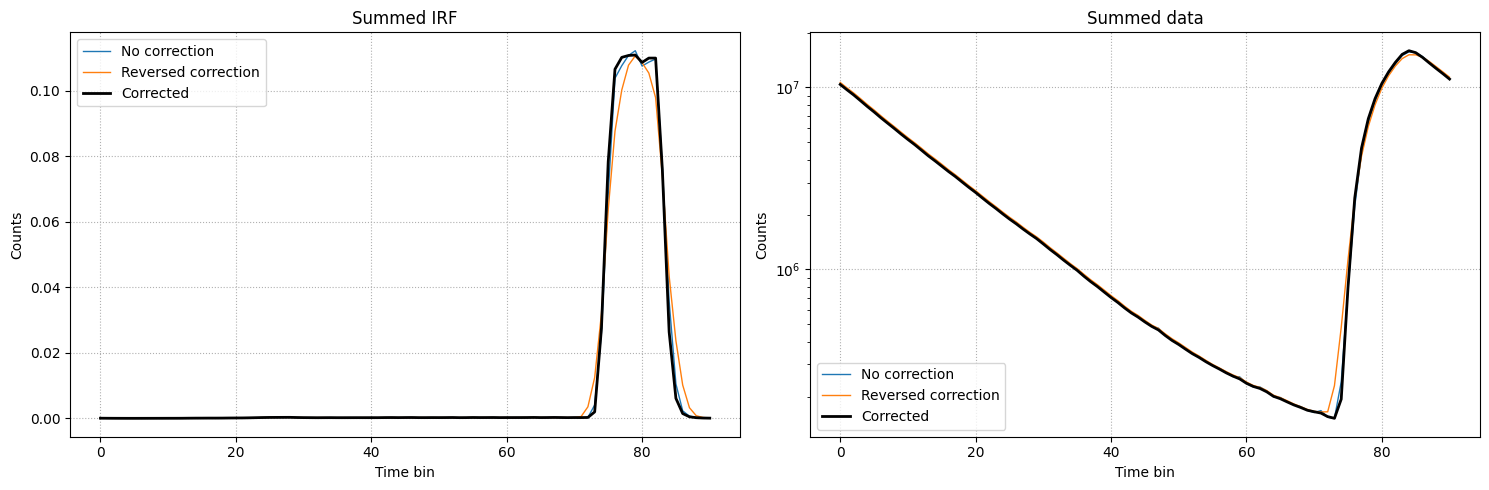

In [6]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)


## Check One Pixel Fit


{'C': 1.0,
 'dT': 0.2268547300885631,
 'dT_ns': 0.06232272804630855,
 'tau': 3.9892880683936083,
 'params': {'C': 1.0, 'dT': 0.2268547300885631, 'tau': 3.9892880683936083},
 'parameter_names': ['C', 'dT', 'tau'],
 'param_values': array([1.        , 0.22685473, 3.98928807]),
 'param_errors': array([       nan, 0.2244659 , 0.14192115]),
 'fit': array([0.03201331, 0.02988732, 0.02790171, 0.02604744, 0.02431605,
        0.02269954, 0.0211905 , 0.01978202, 0.01846747, 0.01724055,
        0.01609551, 0.01502696, 0.01402969, 0.0130991 , 0.01223157,
        0.01142283, 0.01066837, 0.00996463, 0.00930776, 0.008695  ,
        0.00812431, 0.00759255, 0.00709703, 0.00663639, 0.0062092 ,
        0.00581311, 0.00544559, 0.00510358, 0.00478502, 0.0044881 ,
        0.00420854, 0.00394524, 0.0036982 , 0.00346664, 0.00325088,
        0.00304993, 0.00286182, 0.00268617, 0.00252242, 0.00236987,
        0.00222744, 0.00209433, 0.00197032, 0.00185577, 0.00174961,
        0.00164982, 0.00155739, 0.00147176, 

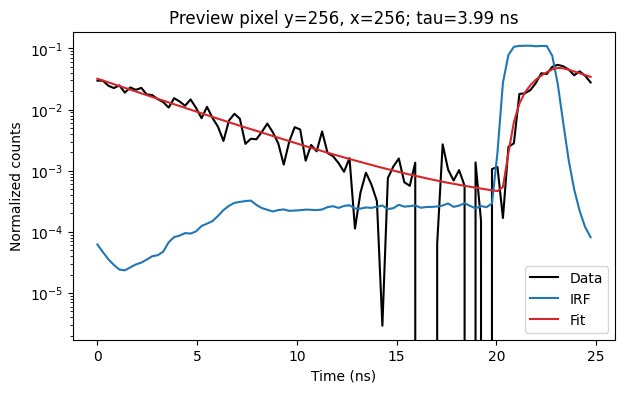

In [7]:
preview_y = data_summed.shape[0] // 2
preview_x = data_summed.shape[1] // 2
preview_hist = data_summed[preview_y, preview_x, :]

preview_result, preview_cov = Alignment.perform_fit_data(
    t=t,
    data=preview_hist,
    irf=irf_summed,
    period=laser_period_ns,
    initial_tau=4.0,
    initial_dT=1.0,
    initial_C=1.0,
    mode='irf_shift',
    fit_type='likelihood',
    force_C_normalized=True,
)

fit_preview = Alignment.fit_model_data(
    t,
    preview_result["C"],
    preview_result["dT"],
    preview_result["tau"],
    irf=irf_summed,
    period=laser_period_ns,
    mode='irf_shift',
)

fit_preview = Alignment.to_numpy_1d(fit_preview, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, preview_hist / preview_hist.sum(), label="Data", color="black")
ax.plot(t, irf_summed / irf_summed.sum(), label="IRF", color="tab:blue")
ax.plot(t, fit_preview / fit_preview.sum(), label="Fit", color="tab:red")
ax.set_yscale("log")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title(f"Preview pixel y={preview_y}, x={preview_x}; tau={preview_result['tau']:.2f} ns")
ax.legend()
preview_result


## Generate Fit Maps


In [8]:
if not hasattr(Alignment, "generate_fit_maps"):
    raise RuntimeError(
        "The notebook kernel still has an old brighteyes_mcs_file.alignment module loaded. "
        "Rerun the first import cell, or restart the kernel and run from the top."
    )

fit_maps = Alignment.generate_fit_maps(
    data=data_summed,
    irf=irf_summed,
    t=t,
    period=laser_period_ns,
    initial_tau=4.0,
    initial_dT=1.0,
    initial_C=1.0,
    mode='irf_shift',
    fit_type='likelihood',
    force_C_normalized=True,
    n_jobs=-1,
)

fit_stack, fit_stack_names = Alignment.fit_maps_to_stack(fit_maps)
print("fit_stack shape:", fit_stack.shape)
print("fit_stack axis 0:", fit_stack_names)


Fitting pixel chunks:   0%|          | 0/288 [00:00<?, ?it/s]

fit_stack shape: (6, 512, 512)
fit_stack axis 0: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


## Visualize Lifetime Fit


In [9]:
tau = fit_maps["tau"]
intensity = data_summed.sum(axis=-1)

thresholded_tau, thresholded_intensity, lifetime_mask = graph.threshold_lifetime_map(
    tau,
    intensity=intensity,
    threshold=0.05,
)

print("finite tau pixels:", np.count_nonzero(np.isfinite(tau)))
print("thresholded pixels:", thresholded_tau.size)


finite tau pixels: 262144
thresholded pixels: 262144


/home/mdonato/.local/share/mamba/envs/venv-3.12/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:733: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

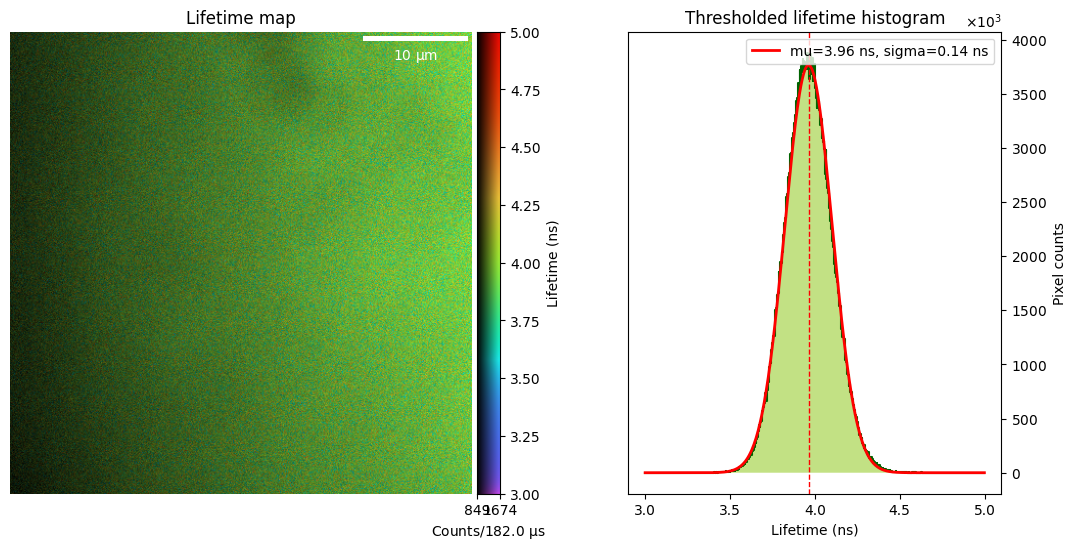

In [10]:
graph.plot_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[3.0, 5.0],
    crop=30,
    threshold=0.05,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:813: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

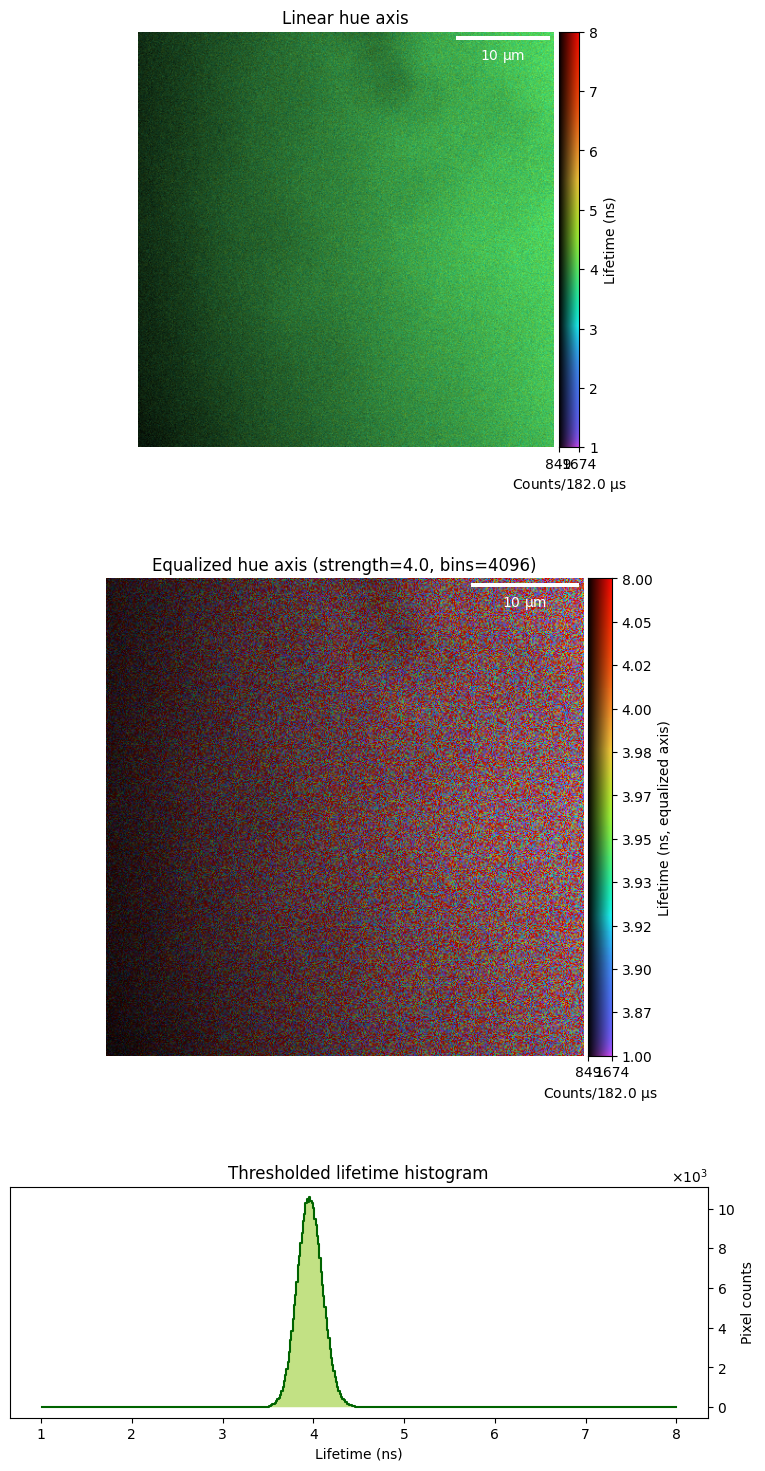

In [11]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 8.0],
    crop=30,
    threshold=0.05,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)
